In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn

## Read the data 


In [29]:
df = pd.read_csv('./data/Dry_Bean_Dataset - Dry_Bean_Dataset.csv')
print(df.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

### 2. Print the total number of:
o Samples (rows)
o Features (columns)


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

### How many unique classes are present in the dataset?

In [31]:
unique_classes = df['Class'].value_counts()
print(unique_classes) ##  => 7 unique classes

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


### . Is the dataset balanced or imbalanced?
o Justify your answer.
o Support your explanation with a visualization (e.g., a bar chart showing
class distribution).


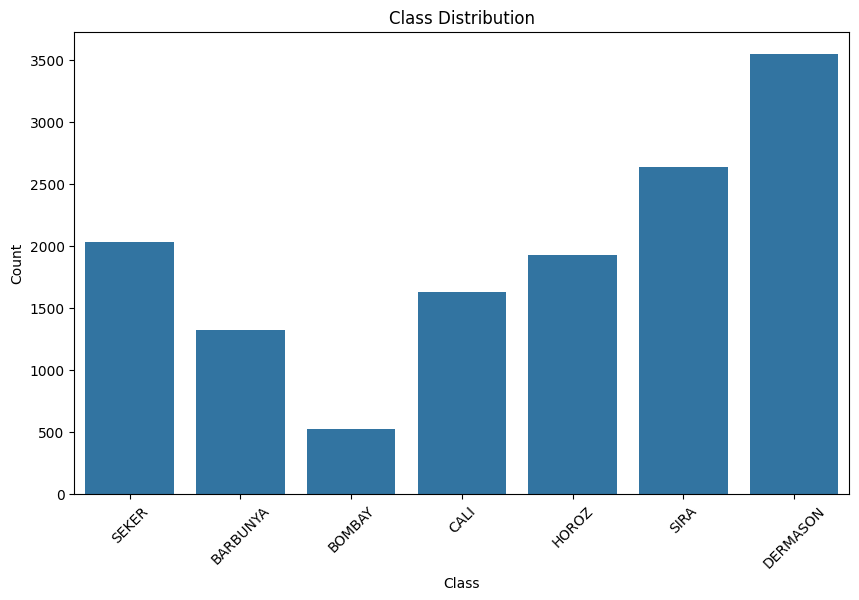

In [32]:
  
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Part 2: Data Exploration & Preprocessing:

In [33]:
# 1. Check whether the dataset contains any missing value.
missing_values = df.isnull().sum()
print(missing_values)

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


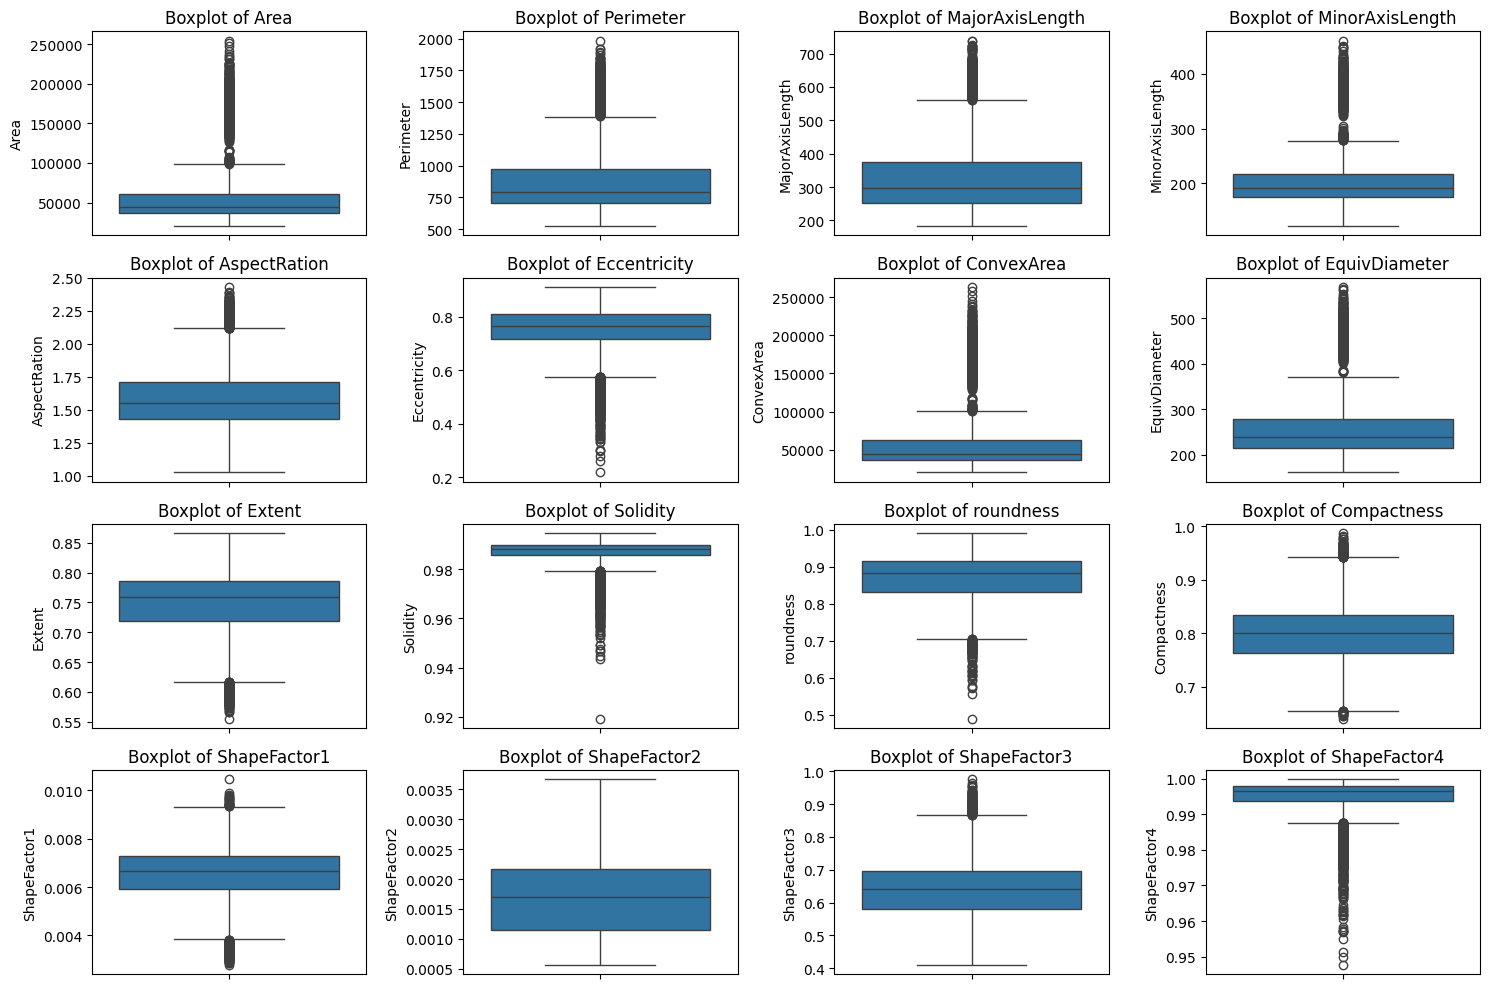

In [34]:
#2. Detect potential outliers using an appropriate statistical method (e.g., IQR or
# Z-score)

# boxplot for each feature to visually inspect for outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1], 1):  # Exclude the 'Class' column
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [35]:
# remove outlires from Area
# Area
# Perimeter
# MajorAxisLength
# MinorAxisLength
# AspectRation
# Eccentricity
# ConvexArea
# EquivDiameter
# Extent
#Solidity
#roundness
# Compactness
#ShapeFactor1
# ShapeFactor3
# ShapeFactor4
#   make a function for loop to remove outliers from all the features
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

features_to_check = ['Area', 'ConvexArea', 'Perimeter', 'MajorAxisLength', 'EquivDiameter', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor3', 'ShapeFactor4']
for feature in features_to_check:
    df = remove_outliers(df, feature)       






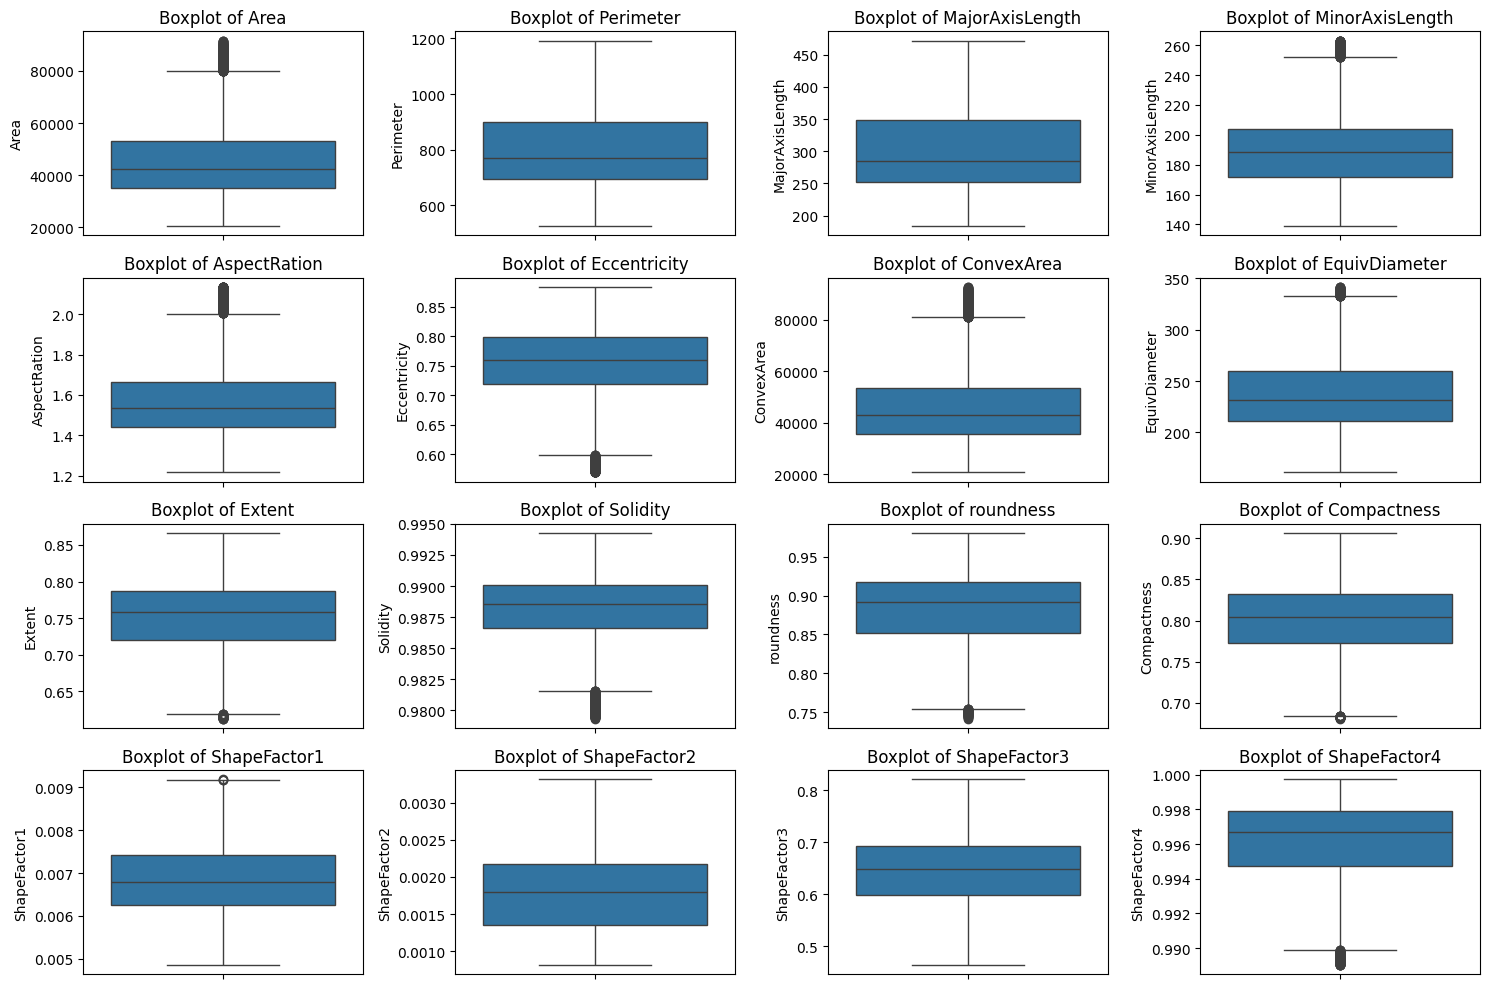

In [36]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1], 1):  # Exclude the 'Class' column
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()


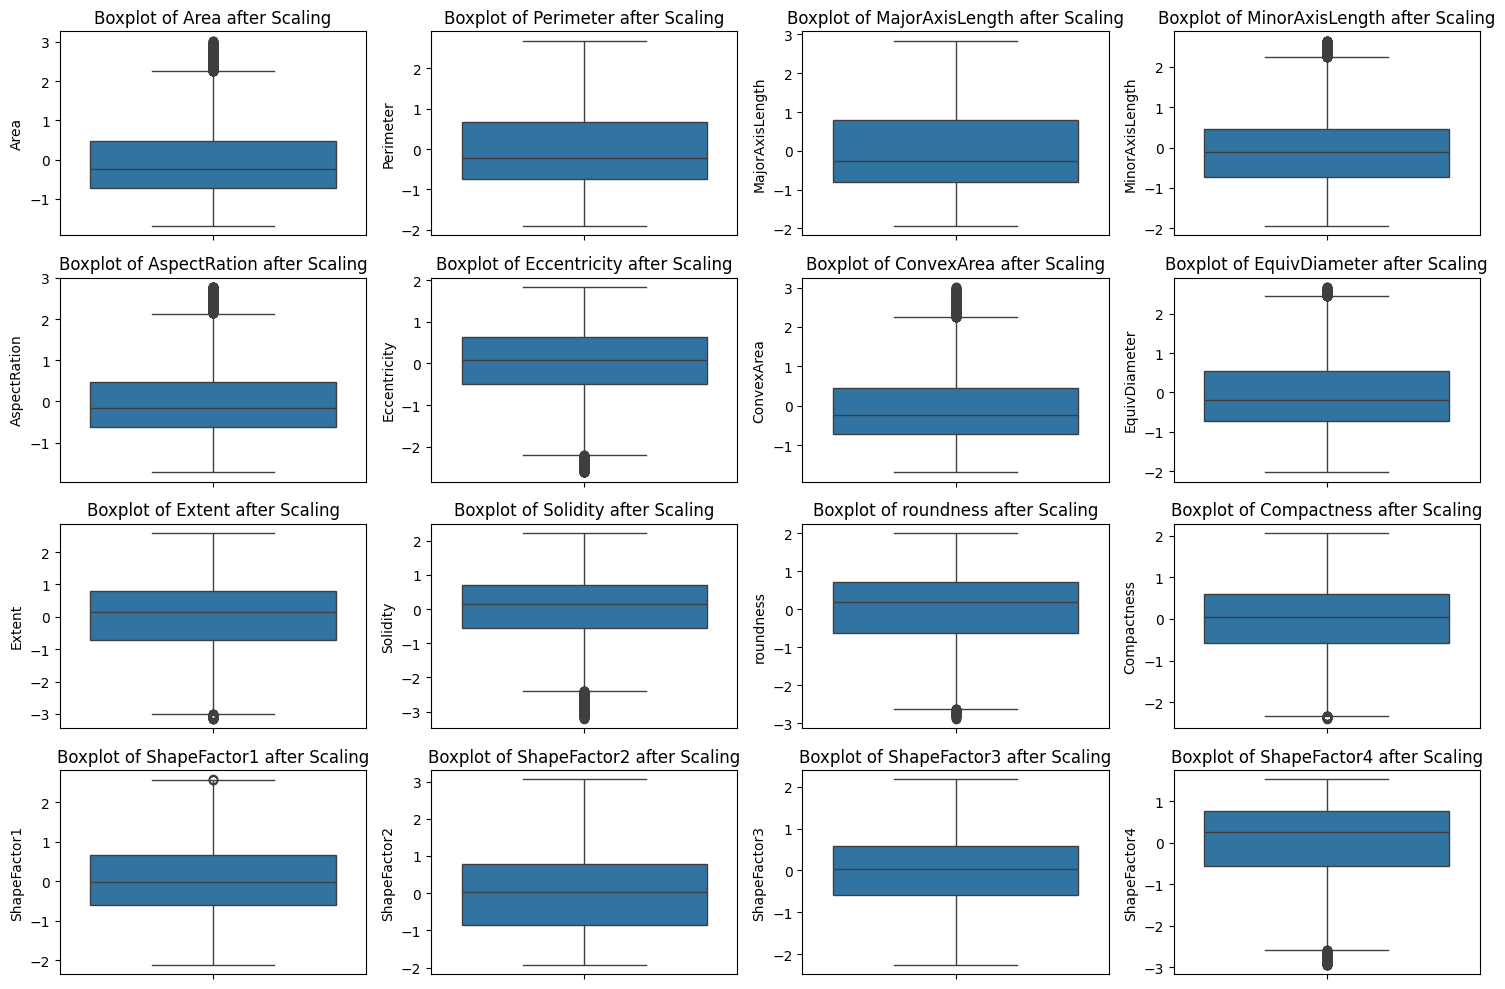

In [41]:
## make scalling by  StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = df.columns[:-1]  # Exclude the 'Class' column
df[features] = scaler.fit_transform(df[features])
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1], 1):  # Exclude the 'Class' column
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column} after Scaling')
plt.tight_layout()
plt.show()
# VARIABLE X , Y AFTER SCALLING
X = df.drop('Class', axis=1)
y = df['Class']

### 4. Explain why feature scaling significantly affects KNN performance.


## part 3 : TRAIN-TEST SPLIT 

In [ ]:
# Split the dataset using:
# • Stratified train-test split
# • Non stratified train-test split
# • Show distribution of classes in both
from sklearn.model_selection import train_test_split
# Stratified train-test split
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Non-stratified train-test split
X_train_non_strat, X_test_non_strat, y_train_non_strat, y_test_non_strat = train_test_split(X, y, test_size=0.2, random_state=42)
# Show distribution of classes in both splits
print("Stratified Split Class Distribution:")
print(y_train_strat.value_counts())
print("\nNon-Stratified Split Class Distribution:")
print(y_train_non_strat.value_counts()) 


Stratified Split Class Distribution:
Class
DERMASON    2753
SIRA        2038
SEKER        996
HOROZ        873
CALI         833
BARBUNYA     729
Name: count, dtype: int64

Non-Stratified Split Class Distribution:
Class
DERMASON    2773
SIRA        2034
SEKER        980
HOROZ        865
CALI         838
BARBUNYA     732
Name: count, dtype: int64


In [ ]:
### 2. Compare model performance using:
# o 70% training / 30% testing
# o 80% training / 20% testing
# Discuss whether performance changes and why

# 70% training / 30% testing
X_train_70, X_test_30, y_train_70, y_test_30  = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# 80% training / 20% testing
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Discuss whether performance changes and why  
print("70% Training / 30% Testing Class Distribution:")
print(y_train_70.value_counts())
print("\n80% Training / 20% Testing Class Distribution:")
print(y_train_80.value_counts())


# THE BEST PEROFMANCE IS 80% TRAINING / 20% TESTING BECAUSE IT HAS MORE DATA TO TRAIN THE MODEL AND LESS DATA TO TEST THE MODEL, WHICH CAN LEAD TO BETTER GENERALIZATION AND HIGHER ACCURACY.


70% Training / 30% Testing Class Distribution:
Class
DERMASON    2409
SIRA        1783
SEKER        871
HOROZ        764
CALI         729
BARBUNYA     638
Name: count, dtype: int64

80% Training / 20% Testing Class Distribution:
Class
DERMASON    2753
SIRA        2038
SEKER        996
HOROZ        873
CALI         833
BARBUNYA     729
Name: count, dtype: int64


###  1: KNN Implementation & Hyperparameter


In [ ]:


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_80, y_train_80)
y_pred_80 = knn.predict(X_test_20)
accuracy_80 = accuracy_score(y_test_20, y_pred_80)
f1_80 = f1_score(y_test_20, y_pred_80, average='weighted')
print(f"Accuracy: {accuracy_80}")
print(f"F1-score: {f1_80}") 



Accuracy: 0.9080739299610895
F1-score: 0.9081422883838343


### 2 . Perform hyperparameter tuning:


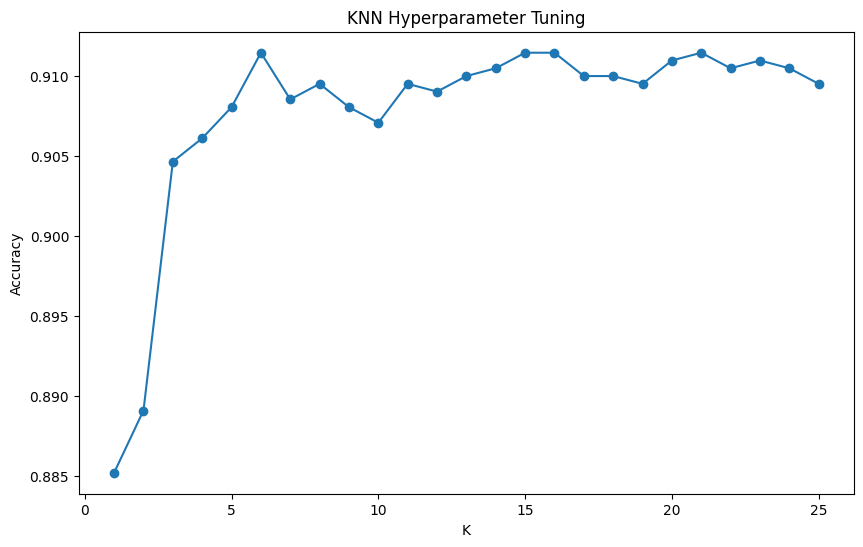

In [ ]:


k_values = range(1, 26)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_80, y_train_80)
    y_pred_k = knn.predict(X_test_20)
    accuracy_k = accuracy_score(y_test_20, y_pred_k)
    accuracies.append(accuracy_k)
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Hyperparameter Tuning')
plt.show()

### 3. Compare different distance metrics:
o Euclidean
o Manhattan

In [ ]:


distance_metrics = ['euclidean', 'manhattan']
for metric in distance_metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train_80, y_train_80)
    y_pred_metric = knn.predict(X_test_20)
    accuracy_metric = accuracy_score(y_test_20, y_pred_metric)
    f1_metric = f1_score(y_test_20, y_pred_metric, average='weighted')
    print(f"Distance Metric: {metric}")
    print(f"Accuracy: {accuracy_metric}")
    print(f"F1-score: {f1_metric}\n")


Distance Metric: euclidean
Accuracy: 0.9080739299610895
F1-score: 0.9081422883838343

Distance Metric: manhattan
Accuracy: 0.9056420233463035
F1-score: 0.9056021187867622



### 4. Discuss when Manhattan distance might outperform Euclidean distance.

When movement happens only horizontally and vertically (like city streets or chess rook movement), Manhattan distance models reality better.

## Part 5: Confusion Matrix Analysis:
1. Plot the confusion matrix of the best-performing model.
2. Identify which classes are most frequently misclassified.

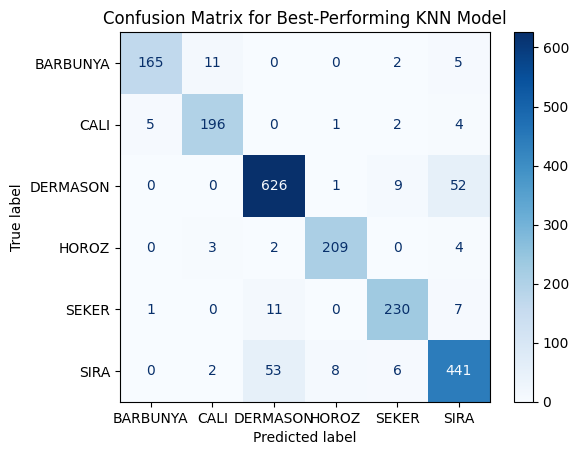

In [52]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Assuming the best-performing model is the one with 'euclidean' distance metric    
best_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
best_knn.fit(X_train_80, y_train_80)
y_pred_best = best_knn.predict(X_test_20)
cm = confusion_matrix(y_test_20, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best-Performing KNN Model')
plt.show()

## Part 6: Try to make KNN Faster(Optional)
To improve KNN performance you can use vectorization, it mainly speeds up the
distance computation step, which is the most expensive part of KNN (search to
learn more about it)

In [54]:
#Part 6: Try to make KNN Faster(Optional)
#To improve KNN performance you can use vectorization, it mainly speeds up the
#distance computation step, which is the most expensive part of KNN (search to
# learn more about it)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score    

scoring_metrics = ['accuracy', 'f1_weighted']
for metric in scoring_metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
    knn.fit(X_train_80, y_train_80)
    y_pred_metric = knn.predict(X_test_20)
    accuracy_metric = accuracy_score(y_test_20, y_pred_metric)
    f1_metric = f1_score(y_test_20, y_pred_metric, average='weighted')
    print(f"Distance Metric: euclidean")
    print(f"{metric.capitalize()}: {accuracy_metric if metric == 'accuracy' else f1_metric}\n")


    

Distance Metric: euclidean
Accuracy: 0.9080739299610895

Distance Metric: euclidean
F1_weighted: 0.9081422883838343

